In [16]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt


# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [17]:
df_us = df[df['job_country'] == "United States"].copy()
df_us['job_posted_month'] = df['job_posted_date'].dt.strftime('%B')
df_us_pivoted = df_us.pivot_table(index = 'job_posted_month', columns = 'job_title_short', aggfunc = 'size')
df_us_pivoted.reset_index('job_posted_month',inplace = True)
df_us_pivoted['Month_no'] = pd.to_datetime(df_us_pivoted['job_posted_month']).dt.month
df_us_pivoted.sort_values(by='Month_no',inplace = True)
df_us_pivoted.set_index('job_posted_month',inplace = True)
df_us_pivoted.drop('Month_no', axis = 1, inplace= True)
df_us_pivoted

C:\Users\arjun\AppData\Local\Temp\ipykernel_1284\2366439685.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_us_pivoted['Month_no'] = pd.to_datetime(df_us_pivoted['job_posted_month']).dt.month


job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [18]:
df_us_software_pivot = pd.read_csv('https://lukeb.co/software_csv',index_col="job_posted_month")
df_us_software_pivot


,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [20]:
df_us_merged = df_us_pivoted.merge(df_us_software_pivot, on = "job_posted_month")

In [30]:
top_5 = (
    df_us_merged.sum()
    .sort_values(ascending = False)
    .head()
    .index
    .to_list()
)
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

(0.0, 20000.0)

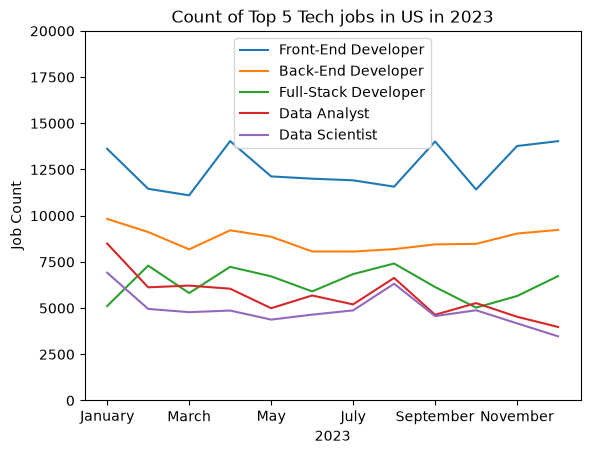

In [39]:
df_us_merged[top_5].plot(kind="line")
plt.title("Count of Top 5 Tech jobs in US in 2023")
plt.xlabel("2023")
plt.ylabel("Job Count")
plt.ylim(0,20000)